In [1]:
%pwd

'/home/tzuhsuan/GitHub/QFoam/High-fidelity-Rydberg-control-Z-gates-with-time-optimal-pulses/Manuscript-figures'

In [2]:
import os
import glob
import time
from IPython.display import clear_output

from qutip import *
import math

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from rdquantum.pulse_shape import Saffman_shape
from rdquantum.fidelity import fidelity
from rdquantum.optimizer.de import de

# plt.rcParams["figure.figsize"] = [8, 5]
plt.rcParams["figure.figsize"] = [8, 7]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.linewidth"] = 2.50
plt.figure(dpi=1200)

<Figure size 9600x8400 with 0 Axes>

<Figure size 9600x8400 with 0 Axes>

In [3]:
op_pulse = []
out_init01 = []
out_init11 = []

# Add Gaussian500_53S_5L_BrrX
root_dir = "Gaussian500_53S_5L_BrrX"
data_dir_prefix = "Gaussian500_53S_5L_Brr"
brr = [50, 500]
for i in range(len(brr)):
    op_pulse.append(np.load("../{}/{}{}/out-op_pulse.npz".format(root_dir, data_dir_prefix, brr[i]), allow_pickle=True))
    
    # popevo01
    out_init01_file = "../{}/{}{}/out_init01.npz".format(root_dir, data_dir_prefix, brr[i])
    out_init01.append(np.load(out_init01_file, allow_pickle=True))

    # popevo11
    out_init11_file = "../{}/{}{}/out_init11.npz".format(root_dir, data_dir_prefix, brr[i])
    out_init11.append(np.load(out_init11_file, allow_pickle=True))
    
# # Add Gaussian500_DeltaX
root_dir = "Gaussian500_DeltaX"
data_dir_prefix = "Gaussian500_Delta"
delta_p = [2]
for i in range(len(delta_p)):
    op_pulse.append(np.load("../{}/{}{}/out-op_pulse.npz".format(root_dir, data_dir_prefix, delta_p[i]), allow_pickle=True))
    
    # popevo01
    out_init01_file = "../{}/{}{}/out_init01.npz".format(root_dir, data_dir_prefix, delta_p[i])
    out_init01.append(np.load(out_init01_file, allow_pickle=True))

    # popevo11
    out_init11_file = "../{}/{}{}/out_init11.npz".format(root_dir, data_dir_prefix, delta_p[i])
    out_init11.append(np.load(out_init11_file, allow_pickle=True))

In [4]:
pulse_Omega1 = []
pulse_Omega2 = []
pulse_Delta1 = []

for i in range(len(brr+delta_p)):
    Omega1 = op_pulse[i]['Omega1']
    Omega2 = op_pulse[i]['Omega2']
    Delta1 = op_pulse[i]['Delta1']
    T_gate = op_pulse[i]['T_gate']
    
    Pulses = {'Omega1': Omega1, 'Omega2': Omega2, 
              'Delta1': Delta1, 
              'T_gate': T_gate}
    times = np.linspace(0.0, T_gate, 100)

    # Pulse shape
    T_gate = Pulses['T_gate'][0]         # (mu s) Total gate time
    n = 12   # Number of segments
    dt = T_gate/n       # (mu s) Duration of each segment

    def gaussian(t):
        # return Saffman_shape(t, Pulses['Omega1'], T_gate, n_seg)
        t = t % T_gate
        t0 = T_gate/2
        tau = 0.165*T_gate
        a = np.exp(- t0**2 / tau**2)
        return Pulses['Omega1'][0] * (np.exp(-(t-t0)**2 / tau**2) - a) / (1-a)

    pulse_Omega1_temp = []
    pulse_Omega2_temp = []
    pulse_Delta1_temp = []
    for t in times:
        pulse_Omega1_temp.append( gaussian(t))
        pulse_Omega2_temp.append( Omega2[0] )
        pulse_Delta1_temp.append( Delta1[0] )

    pulse_Omega1.append(pulse_Omega1_temp)
    pulse_Omega2.append(pulse_Omega2_temp)
    pulse_Delta1.append(pulse_Delta1_temp)

/tmp/ipykernel_72566/1963294880.py:93: MatplotlibDeprecationWarning: Passing the emit parameter of set_ylim() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  axht.set_ylim(2.25, 0, -1)


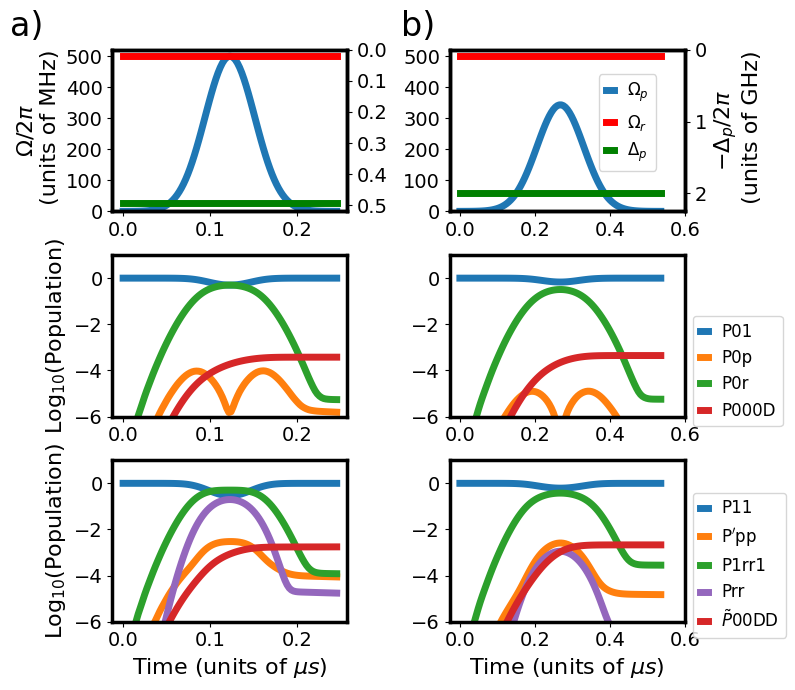

In [14]:
fig, axs = plt.subplots(3,2)

# axa = axs[0,0]

# Brr50 
axb = axs[0, 0]
axc = axs[1, 0]
axd = axs[2, 0]

# # Brr500
# axe = axs[0, 1]
# axf = axs[1, 1]
# axg = axs[2, 1]

# Delta2
axh = axs[0, 1]
axi = axs[1, 1]
axj = axs[2, 1]


###### a)
times = np.linspace(0.0, op_pulse[0]['T_gate'],  100)
xinterval = np.arange(0, 0.26, 0.1)
#axb
axbp = axb.plot(times, pulse_Omega1[0], linewidth=5, label=r'$\Omega_p$')
axbp2 = axb.plot(times, pulse_Omega2[0], linewidth=5, label=r'$\Omega_r$', color='r')
axbt = axb.twinx()
axbtp = axbt.plot(times, [-x/1000 for x in pulse_Delta1[0]], linewidth=5, label=r'$\Delta_p$', color='g')
axbld = axbp + axbp2 + axbtp
axblb = [lb.get_label() for lb in axbld]
# axb.legend(axbld, axblb, bbox_to_anchor=(.676, .425), fontsize=10)

axb.set_ylim(0, 520)
axbt.set_ylim(0.52, 0)
axb.set_ylabel(r'$\Omega / 2 \pi$' '\n' ' (units of MHz)', fontsize=16)
axb.set_xticks(xinterval)
yinterval = np.arange(0, 520, 100)
y1interval = np.arange(0.5, -0.02, -0.1)
axb.set_yticks(yinterval)
axbt.set_yticks(y1interval)
axb.tick_params(axis='x', labelsize=14)
axb.tick_params(axis='y', labelsize=14)
axbt.tick_params(axis='y', rotation=0, labelsize=14)
axb.set_title('a)', x=-0.365, pad=10, fontsize=24)


#axc
axc.plot(times, out_init01[0]["P01"], linewidth=5) 
axc.plot(times, out_init01[0]["P0p"], linewidth=5)
axc.plot(times, out_init01[0]["P0r"], linewidth=5)
axc.plot(times, out_init01[0]["P000d"], linewidth=5)
axc.set_ylim(-6, 1)
axc.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=16) 
# axc.legend(("P01", "P0p", "P0r", "P000D"), fontsize=10)
axc.set_xticks(xinterval)
axc.tick_params(axis='x', labelsize=14)
axc.tick_params(axis='y', labelsize=14)
# axc.set_title('b)', loc='left', pad=10)

#axd
axd.plot(times, out_init11[0]["P11"], linewidth=5) 
axd.plot(times, out_init11[0]["Ppp"], linewidth=5)
axd.plot(times, out_init11[0]["P1rr1"], linewidth=5)
axd.plot(times, out_init11[0]["Prr"], linewidth=5, color='tab:purple')
axd.plot(times, out_init11[0]["P00dd"], linewidth=5, color='tab:red')
axd.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=16)
axd.set_ylim(-6, 1)
axd.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=16) 
# axd.legend(("P11", "P" r"$'$" "pp", "P1rr1", "Prr", r"$\tilde{P}$""00DD"), fontsize=10)
axd.set_xticks(xinterval)
axd.tick_params(axis='x', labelsize=14)
axd.tick_params(axis='y', labelsize=14)
# axd.set_title('c)', loc='left', pad=10)


# c)
times = np.linspace(0.0, op_pulse[2]['T_gate'],  100)
xinterval = np.arange(0, 0.62, 0.2)
#axh
axhp = axh.plot(times, pulse_Omega1[2], linewidth=5, label=r'$\Omega_p$')
axhp2 = axh.plot(times, pulse_Omega2[2], linewidth=5, label=r'$\Omega_r$', color='r')
axht = axh.twinx()
axhtp = axht.plot(times, [-x/1000 for x in pulse_Delta1[2]], linewidth=5, label=r'$\Delta_p$', color='g')
axhld = axhp + axhp2 + axhtp
axhlb = [lb.get_label() for lb in axhld]
axh.legend(axhld, axhlb, bbox_to_anchor=(.6, .55), fontsize=12, handlelength=0.5)

# axht.set_ylabel(r'$\Delta_p / 2 \pi$' '\n' ' (units of GHz)', fontsize=16)
axht.set_ylabel(r'$-\Delta_p / 2 \pi$' '\n' ' (units of GHz)', fontsize=16)
# axh.set_ylabel(r'$\Omega(\Delta_p) / 2 \pi$' '\n' ' (units of MHz)', fontsize=16)
# axh.legend(bbox_to_anchor=(1., .825), fontsize=14)
axh.set_ylim(0, 520)
axht.set_ylim(2.25, 0, -1)
axh.set_xticks(xinterval)
yinterval = np.arange(0, 520, 100)
axh.set_yticks(yinterval)
axh.tick_params(axis='x', labelsize=14)
axh.tick_params(axis='y', labelsize=14)
axht.tick_params(axis='y', rotation=0, labelsize=14)
axh.set_title('b)', x=-0.135, pad=10, fontsize=24)

#axi
axi.plot(times, out_init01[2]["P01"], linewidth=5) 
axi.plot(times, out_init01[2]["P0p"], linewidth=5)
axi.plot(times, out_init01[2]["P0r"], linewidth=5)
axi.plot(times, out_init01[2]["P000d"], linewidth=5)
# axi.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=12)
axi.set_ylim(-6, 1)
axi.legend(("P01", "P0p", "P0r", "P000D"), bbox_to_anchor=(1., .675), fontsize=12, handlelength=0.5)
axi.set_xticks(xinterval)
axi.tick_params(axis='x', labelsize=14)
axi.tick_params(axis='y', labelsize=14)
# axi.set_title('e)', loc='left', pad=10)

#axj
axj.plot(times, out_init11[2]["P11"], linewidth=5) 
axj.plot(times, out_init11[2]["Ppp"], linewidth=5)
axj.plot(times, out_init11[2]["P1rr1"], linewidth=5)
axj.plot(times, out_init11[2]["Prr"], linewidth=5, color='tab:purple')
axj.plot(times, out_init11[2]["P00dd"], linewidth=5, color='tab:red')
axj.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=16)
axj.set_ylim(-6, 1)
axj.legend(("P11", "P" r"$'$" "pp", "P1rr1", "Prr", r"$\tilde{P}$""00DD"), bbox_to_anchor=(1., .85), fontsize=12, handlelength=0.5)
axj.set_xticks(xinterval)
# axj.set_title('f)', loc='left', pad=10)
axj.tick_params(axis='x', labelsize=14)
axj.tick_params(axis='y', labelsize=14)

plt.savefig('fig3.eps', dpi=1200)